In [ ]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

In [ ]:
# ============================================================
# Paths
# ============================================================

INPUT_PATH = Path(
    "/Users/ilg/Desktop/year4/M4R/python_files/some_other_eda/biclust_metric_with_dataset_names.csv"
)

OUTPUT_DIR = Path(
    "/Users/ilg/Desktop/year4/M4R/python_files/some_other_eda/dataset_hierarchical_clustering"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# Settings
# ============================================================

ID_COLS = ["dataset_id", "file_stem"]
N_CLUSTERS = 5

# Hierarchical clustering setting.
LINKAGE_METHOD = "ward"
DISTANCE_METRIC = "euclidean"

sns.set_context("notebook")

In [40]:
df = pd.read_csv(INPUT_PATH)

metric_cols = [c for c in df.columns if c not in ID_COLS]

print("Data shape:", df.shape)
print("Number of metric columns:", len(metric_cols))
print(metric_cols)


def parse_p_number(s):
    """
    Converts strings like '0p75' to 0.75.
    """
    if s is None:
        return np.nan
    return float(str(s).replace("p", "."))


def parse_file_stem(stem):
    """
    Expected examples:
    synth_0001_additive_K2_C0p75_O0p00_very_sparse...
    """
    stem = str(stem)

    out = {
        "model_family": "unknown",
        "K_true": np.nan,
        "contrast": np.nan,
        "overlap": np.nan,
        "shape_label": "unknown",
    }

    # Model family
    if "_additive_" in stem:
        out["model_family"] = "additive"
    elif "_multiplicative_" in stem:
        out["model_family"] = "multiplicative"
    elif "_null_" in stem or "null" in stem.lower():
        out["model_family"] = "null"

    # K, contrast, overlap
    k_match = re.search(r"_K(\d+)", stem)
    c_match = re.search(r"_C([0-9p]+)", stem)
    o_match = re.search(r"_O([0-9p]+)", stem)

    if k_match:
        out["K_true"] = int(k_match.group(1))
    if c_match:
        out["contrast"] = parse_p_number(c_match.group(1))
    if o_match:
        out["overlap"] = parse_p_number(o_match.group(1))

    # Shape/sparsity label: everything after overlap token
    # This will not be perfect, but it is good enough for annotation.
    shape_match = re.search(r"_O[0-9p]+_(.+)$", stem)
    if shape_match:
        shape = shape_match.group(1)

        # Remove common seed suffixes if present.
        shape = re.sub(r"_seed\d+.*$", "", shape)
        shape = re.sub(r"_rep\d+.*$", "", shape)
        shape = re.sub(r"_\d+$", "", shape)

        out["shape_label"] = shape

    return pd.Series(out)


metadata = df["file_stem"].apply(parse_file_stem)

df_meta = pd.concat([df[ID_COLS], metadata, df[metric_cols]], axis=1)

print(df_meta[["dataset_id", "file_stem", "model_family", "K_true", "contrast", "overlap", "shape_label"]].head(10))
print("\nModel family counts:")
print(df_meta["model_family"].value_counts(dropna=False))

print("\nContrast counts:")
print(df_meta["contrast"].value_counts(dropna=False).sort_index())

print("\nOverlap counts:")
print(df_meta["overlap"].value_counts(dropna=False).sort_index())

Data shape: (1044, 20)
Number of metric columns: 18
['Plaid_assumed_k2_R2', 'Plaid_assumed_k2_BIC', 'Plaid_assumed_k2_pWTVE', 'Plaid_assumed_k3_R2', 'Plaid_assumed_k3_BIC', 'Plaid_assumed_k3_pWTVE', 'Plaid_assumed_k5_R2', 'Plaid_assumed_k5_BIC', 'Plaid_assumed_k5_pWTVE', 'FABIA_assumed_k2_RMSE', 'FABIA_assumed_k2_AHS', 'FABIA_assumed_k2_SNR', 'FABIA_assumed_k3_RMSE', 'FABIA_assumed_k3_AHS', 'FABIA_assumed_k3_SNR', 'FABIA_assumed_k5_RMSE', 'FABIA_assumed_k5_AHS', 'FABIA_assumed_k5_SNR']
   dataset_id                                          file_stem model_family  \
0           1  synth_0001_additive_K2_C0p75_O0p00_very_sparse...     additive   
1           2  synth_0002_additive_K2_C0p75_O0p00_very_sparse...     additive   
2           3  synth_0003_additive_K2_C0p75_O0p00_very_sparse...     additive   
3           4  synth_0004_additive_K2_C0p75_O0p00_sparse_loca...     additive   
4           5  synth_0005_additive_K2_C0p75_O0p00_sparse_loca...     additive   
5           6  synth_00

In [41]:
# ============================================================
# Block 3: sigmoid normalisation of the designed metrics
# ============================================================

X = df_meta[metric_cols].copy()

# Safety checks
if X.isna().any().any():
    print("Warning: missing values found. Filling with column medians.")
    X = X.fillna(X.median(numeric_only=True))


def sigmoid_normalise_column(x, eps=1e-12):
    """
    Robust sigmoidal normalisation:
        z = 1 / (1 + exp(-(x - median(x)) / (1.35 * IQR(x))))

    The factor 1.35 makes IQR comparable to standard deviation
    under an approximately normal distribution.
    """
    x = pd.Series(x).astype(float)

    med = x.median()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    if abs(iqr) < eps:
        return pd.Series(np.zeros(len(x)), index=x.index)

    scaled = (x - med) / (1.35 * iqr)

    # Avoid numerical overflow in exp
    scaled = scaled.clip(lower=-50, upper=50)

    z = 1 / (1 + np.exp(-scaled))

    return pd.Series(z, index=x.index)


X_scaled = X.apply(sigmoid_normalise_column, axis=0)

print("Sigmoid-normalised metric matrix shape:", X_scaled.shape)
print(X_scaled.describe().T[["mean", "std", "min", "max"]].head())

Sigmoid-normalised metric matrix shape: (1044, 18)
                            mean       std       min       max
Plaid_assumed_k2_R2     0.571961  0.148022  0.439131  0.971109
Plaid_assumed_k2_BIC    0.553849  0.145567  0.412987  0.979705
Plaid_assumed_k2_pWTVE  0.444442  0.084819  0.270765  0.500000
Plaid_assumed_k3_R2     0.572753  0.155106  0.434733  0.968747
Plaid_assumed_k3_BIC    0.552892  0.150519  0.405075  0.985501


In [42]:
# Compute hierarchical clustering on datasets
Z = linkage(
    X_scaled.values,
    method=LINKAGE_METHOD,
    metric=DISTANCE_METRIC,
)

cluster_labels = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

df_clustered = df_meta.copy()
df_clustered["cluster"] = cluster_labels

# Save cluster assignment file
CLUSTER_ASSIGNMENT_PATH = OUTPUT_DIR / f"metric_dataset_clusters_k{N_CLUSTERS}.csv"
df_clustered.to_csv(CLUSTER_ASSIGNMENT_PATH, index=False)

print("Saved cluster assignments to:")
print(CLUSTER_ASSIGNMENT_PATH)

print("\nCluster sizes:")
print(df_clustered["cluster"].value_counts().sort_index())

Saved cluster assignments to:
/Users/ilg/Desktop/year4/M4R/python_files/some_other_eda/dataset_hierarchical_clustering/metric_dataset_clusters_k5.csv

Cluster sizes:
cluster
1    399
2    351
3    144
4     57
5     93
Name: count, dtype: int64


/Users/ilg/anaconda3/envs/pyspoc_env/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


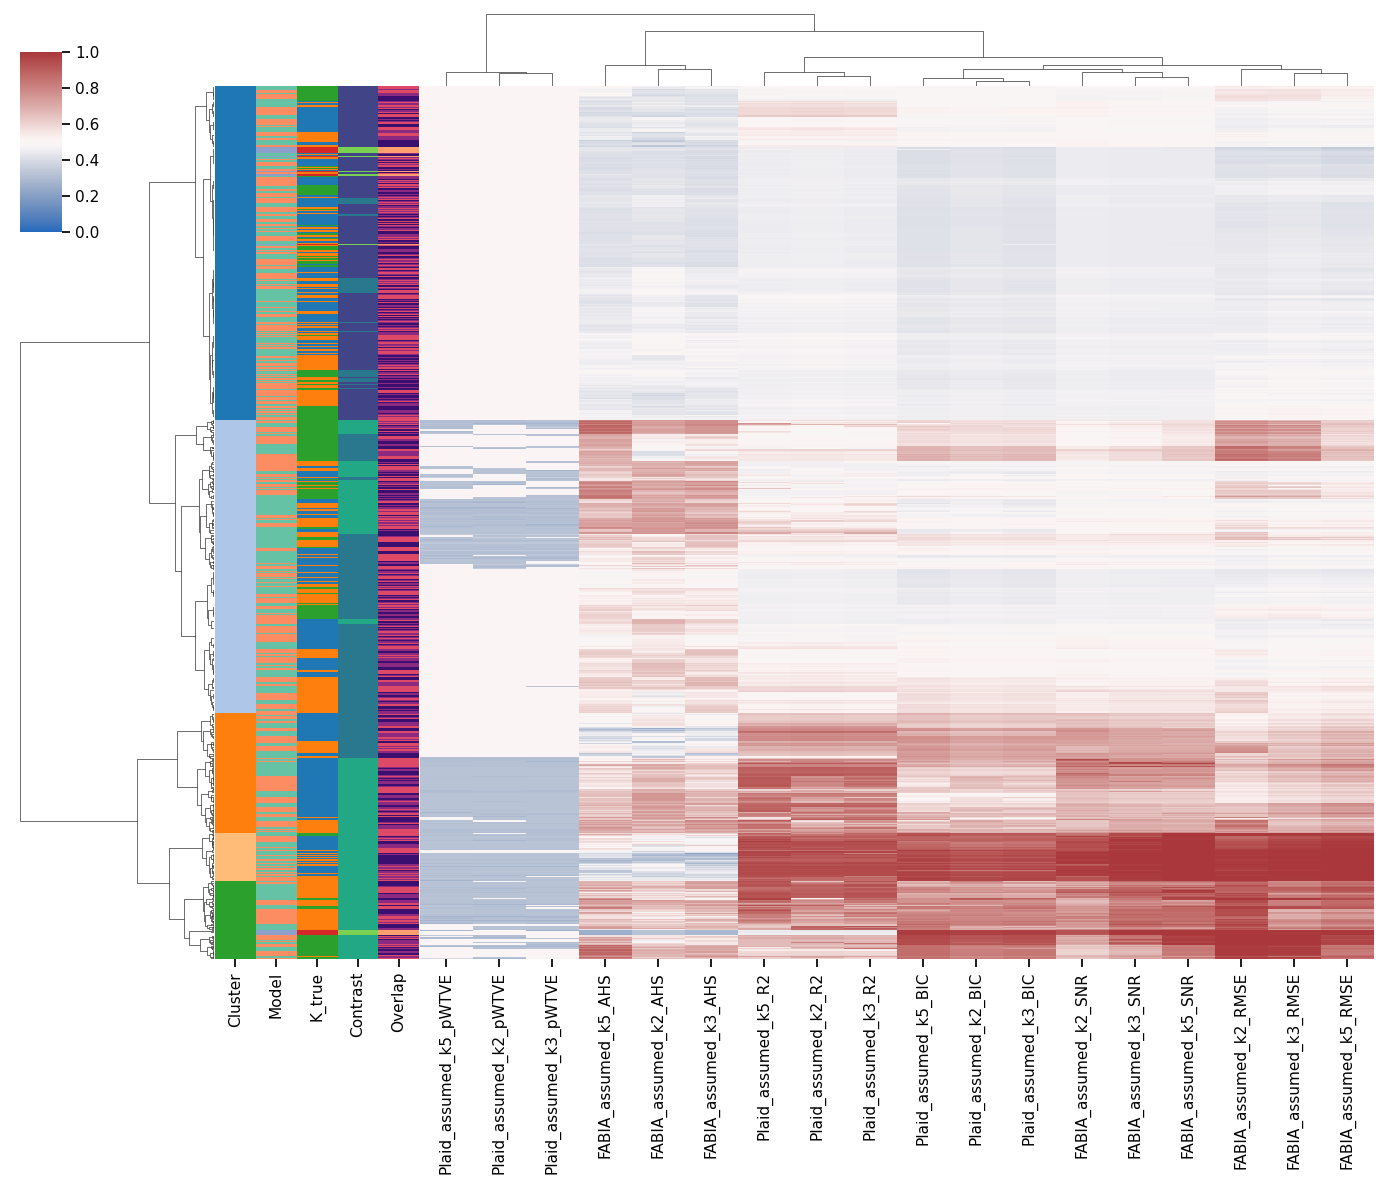

In [ ]:
def make_colour_lut(values, palette_name="tab10"):
    """
    Makes a colour lookup table for categorical values.
    """
    values = pd.Series(values).dropna().unique().tolist()
    values = sorted(values, key=lambda x: str(x))

    palette = sns.color_palette(palette_name, n_colors=len(values))
    return dict(zip(values, palette))


def map_colours(series, lut):
    return series.map(lut)


# Create colour maps for annotations
model_lut = make_colour_lut(df_clustered["model_family"], "Set2")
k_lut = make_colour_lut(df_clustered["K_true"].astype("Int64").astype(str), "tab10")
contrast_lut = make_colour_lut(df_clustered["contrast"].round(3).astype(str), "viridis")
overlap_lut = make_colour_lut(df_clustered["overlap"].round(3).astype(str), "magma")
cluster_lut = make_colour_lut(df_clustered["cluster"].astype(str), "tab20")


row_colors = pd.DataFrame({
    "Cluster": map_colours(df_clustered["cluster"].astype(str), cluster_lut),
    "Model": map_colours(df_clustered["model_family"], model_lut),
    "K_true": map_colours(df_clustered["K_true"].astype("Int64").astype(str), k_lut),
    "Contrast": map_colours(df_clustered["contrast"].round(3).astype(str), contrast_lut),
    "Overlap": map_colours(df_clustered["overlap"].round(3).astype(str), overlap_lut),
}, index=df_clustered.index)


g = sns.clustermap(
    X_scaled,
    row_linkage=Z,
    col_cluster=True,
    row_colors=row_colors,
    cmap="vlag",
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=True,
    yticklabels=False,
    figsize=(14, 12),
    dendrogram_ratio=(0.15, 0.08),
    colors_ratio=(0.03, 0.03),
    cbar_pos=(0.02, 0.80, 0.03, 0.15),
)

plt.savefig(
    OUTPUT_DIR / f"metric_dataset_clustermap_k{N_CLUSTERS}.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [44]:
summary_cols = ["model_family", "K_true", "contrast", "overlap", "shape_label"]

for col in summary_cols:
    print("\n" + "=" * 80)
    print(f"Cluster composition by {col}")
    print("=" * 80)

    tab = pd.crosstab(
        df_clustered["cluster"],
        df_clustered[col],
        normalize="index"
    )

    display(tab.round(3))


# Also summarise the average metric profile in each cluster
cluster_metric_means = (
    df_clustered
    .groupby("cluster")[metric_cols]
    .mean()
    .round(4)
)

print("\nAverage raw metric values by cluster:")
display(cluster_metric_means)

cluster_metric_means.to_csv(
    OUTPUT_DIR / f"cluster_metric_means_k{N_CLUSTERS}.csv"
)


Cluster composition by model_family


model_family,additive,multiplicative,null
cluster,,,
1,0.479,0.491,0.030
2,0.507,0.493,0.000
3,0.500,0.500,0.000
4,0.526,0.474,0.000
5,0.452,0.484,0.065



Cluster composition by K_true


K_true,2.0,3.0,5.0
cluster,,,
1,0.424,0.357,0.220
2,0.353,0.376,0.271
3,0.750,0.250,0.000
4,0.632,0.316,0.053
5,0.000,0.621,0.379



Cluster composition by contrast


...

overlap,0.0,0.2,0.4
cluster,,,
1,0.339,0.333,0.328
2,0.328,0.333,0.339
3,0.333,0.333,0.333
4,0.316,0.316,0.368
5,0.345,0.345,0.310



Cluster composition by shape_label


shape_label,huge_balanced,large_balanced,large_col_dominant,large_row_dominant,medium_balanced,sparse_local,unknown,very_huge_balanced,very_sparse_local
cluster,,,,,,,,,
1,0.090,0.135,0.090,0.093,0.135,0.138,0.030,0.045,0.243
2,0.000,0.154,0.103,0.100,0.154,0.305,0.000,0.000,0.185
3,0.250,0.125,0.125,0.125,0.250,0.000,0.000,0.125,0.000
4,0.632,0.053,0.000,0.000,0.000,0.000,0.000,0.316,0.000
5,0.000,0.355,0.194,0.194,0.194,0.000,0.065,0.000,0.000



Average raw metric values by cluster:


,Plaid_assumed_k2_R2,Plaid_assumed_k2_BIC,Plaid_assumed_k2_pWTVE,Plaid_assumed_k3_R2,Plaid_assumed_k3_BIC,Plaid_assumed_k3_pWTVE,Plaid_assumed_k5_R2,Plaid_assumed_k5_BIC,Plaid_assumed_k5_pWTVE,FABIA_assumed_k2_RMSE,FABIA_assumed_k2_AHS,FABIA_assumed_k2_SNR,FABIA_assumed_k3_RMSE,FABIA_assumed_k3_AHS,FABIA_assumed_k3_SNR,FABIA_assumed_k5_RMSE,FABIA_assumed_k5_AHS,FABIA_assumed_k5_SNR
cluster,,,,,,,,,,,,,,,,,,
1,0.0213,14637.7433,1.0000,0.0213,14646.4276,1.0000,0.0214,14649.7481,1.0000,0.9856,0.2746,0.0463,0.9769,0.2757,0.0617,0.9609,0.2700,0.0909
2,0.0368,22084.3120,0.8100,0.0384,21958.9028,0.7987,0.0391,21881.0081,0.8098,1.0017,0.3987,0.0960,0.9869,0.3885,0.1253,0.9673,0.3550,0.1649
3,0.1607,39397.1062,0.6273,0.1719,38284.4255,0.6174,0.1849,36943.4822,0.6369,1.0152,0.3941,0.3756,0.9997,0.3731,0.4239,0.9848,0.3282,0.4551
4,0.3132,95080.2106,0.4448,0.3237,93965.8634,0.4457,0.3369,92595.0424,0.4378,1.1755,0.2675,1.1812,1.1414,0.2700,3.4224,1.1267,0.2779,6.0732
5,0.1524,68707.6612,0.5595,0.1765,66292.2107,0.5746,0.1850,65256.9796,0.6095,1.1604,0.3889,0.4454,1.0758,0.4008,0.7674,1.0246,0.3861,1.2886


In [45]:
for cl in sorted(df_clustered["cluster"].unique()):
    print("\n" + "=" * 100)
    print(f"Cluster {cl}")
    print("=" * 100)

    sub = df_clustered[df_clustered["cluster"] == cl].copy()

    print("Size:", len(sub))
    print("Model family counts:")
    print(sub["model_family"].value_counts())

    print("\nContrast counts:")
    print(sub["contrast"].value_counts().sort_index())

    print("\nOverlap counts:")
    print(sub["overlap"].value_counts().sort_index())

    print("\nExample datasets:")
    for name in sub["file_stem"].head(10):
        print("  ", name)


Cluster 1
Size: 399
Model family counts:
model_family
multiplicative    196
additive          191
null               12
Name: count, dtype: int64

Contrast counts:
contrast
0.75    342
1.50     45
Name: count, dtype: int64

Overlap counts:
overlap
0.0    131
0.2    129
0.4    127
Name: count, dtype: int64

Example datasets:
   synth_0001_additive_K2_C0p75_O0p00_very_sparse_local_seed0
   synth_0002_additive_K2_C0p75_O0p00_very_sparse_local_seed1
   synth_0003_additive_K2_C0p75_O0p00_very_sparse_local_seed2
   synth_0004_additive_K2_C0p75_O0p00_sparse_local_seed0
   synth_0005_additive_K2_C0p75_O0p00_sparse_local_seed1
   synth_0006_additive_K2_C0p75_O0p00_sparse_local_seed2
   synth_0007_additive_K2_C0p75_O0p00_medium_balanced_seed0
   synth_0008_additive_K2_C0p75_O0p00_medium_balanced_seed1
   synth_0009_additive_K2_C0p75_O0p00_medium_balanced_seed2
   synth_0010_additive_K2_C0p75_O0p00_large_balanced_seed0

Cluster 2
Size: 351
Model family counts:
model_family
additive          178


In [46]:
pd.crosstab(df_clustered["cluster"], df_clustered["contrast"], normalize="index").round(3)
pd.crosstab(df_clustered["cluster"], df_clustered["model_family"], normalize="index").round(3)
pd.crosstab(df_clustered["cluster"], df_clustered["K_true"], normalize="index").round(3)
pd.crosstab(df_clustered["cluster"], df_clustered["overlap"], normalize="index").round(3)

overlap,0.0,0.2,0.4
cluster,,,
1,0.339,0.333,0.328
2,0.328,0.333,0.339
3,0.333,0.333,0.333
4,0.316,0.316,0.368
5,0.345,0.345,0.310
